# Task 2: Perceptron Algorithm for 0 vs 1 Classification

## 1. Objective
In this exercise, we implement a Perceptron learning algorithm for binary classification using the MNIST dataset. Specifically, we will classify the digits 0 and 1. After completing the algorithm, we will evaluate the model's performance and visualize any misclassified images.

## 2. Load the Dataset
We start by loading the MNIST dataset containing digits 0 and 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels (28x28)
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Answer the Following Question:

**Question - 1: What does the shape of X represent?**

The shape of X, `(12665, 784)`, represents:
- `12665`: The total number of images (samples) in the dataset that are either digit 0 or digit 1.
- `784`: The number of features per sample. Since each image is 28x28 pixels, it is flattened into a 1D array of 784 pixels.

**Question - 2: What does the shape of y represent?**

The shape of y, `(12665,)`, represents the labels for each of the 12665 images. Each entry is either 0 or 1, corresponding to the digit shown in the image.

### Visualize the Dataset
Let's see some samples from our dataset.

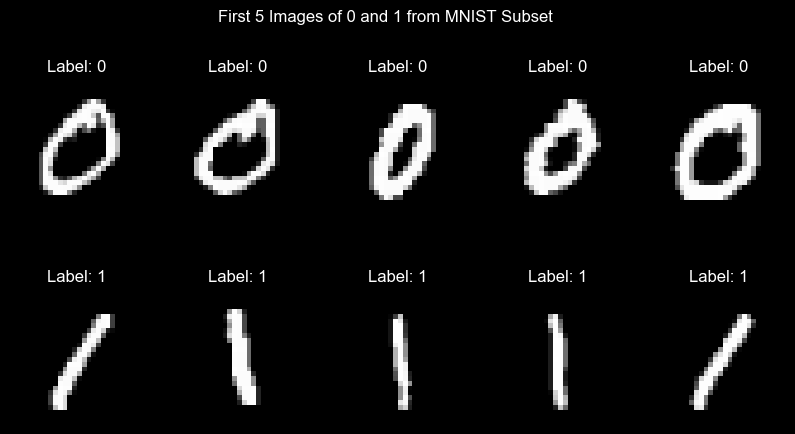

In [2]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    # Plot digit 0
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
    # Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

## 3. Initialize Weights and Bias
We initialize the weights and bias to zero.

In [3]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 10

### Answer the Following Question:

**Question - 3: What does the weights array represent in this context?**

Each element in the weights array corresponds to a specific pixel position in the 28x28 image. The value of the weight represents the importance of that pixel in determining whether the image is a '0' or a '1'.

**Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?**

Initializing weights to zero provides a neutral starting point. In a simple Perceptron, the learning rule will gradually adjust these weights based on classification errors. While zero initialization is fine for a single Perceptron, in deeper networks it can lead to issues like symmetry, but here it simply means the model starts with no prior "knowledge" of which pixels are important.

## 4. Implement a Decision Function or Activation Function

In [4]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """
    # Calculate net input: z = X.w + b
    z = np.dot(X, weights) + bias
    # Activation function (Step function: 1 if z >= 0 else 0)
    y_pred_all = np.where(z >= 0, 1, 0)
    return y_pred_all

## 5. Implement the Perceptron Learning Algorithm

In [5]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """
    n_samples = X.shape[0]
    
    for epoch in range(epochs):
        errors = 0
        for i in range(n_samples):
            # 1. Calculate the linear output
            z = np.dot(X[i], weights) + bias
            
            # 2. Apply step function
            y_hat = 1 if z >= 0 else 0
            
            # 3. Update weights and bias if prediction is wrong
            if y_hat != y[i]:
                update = learning_rate * (y[i] - y_hat)
                weights += update * X[i]
                bias += update
                errors += 1
        
        accuracy = 1 - (errors / n_samples)
        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}: Accuracy = {accuracy:.4f}")
            
        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break
            
    return weights, bias, accuracy

### Answer the Following Question:

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

This line calculates the weighted sum of the input features plus the bias term. It represents the net input to the neuron, which is then passed through an activation function to make a prediction.

**Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?**

If the prediction is wrong, the weights and bias are updated in the direction of the correct label. The update rule is: `new_weight = old_weight + learning_rate * (target - predicted) * input`. This adjustment reduces the error for that sample in future iterations.

**Question - 7: Why is the final accuracy important, and what do you expect it to be?**

Final accuracy tells us how well our model has learned to distinguish between the two classes. For MNIST 0 vs 1, which are very distinct and largely linearly separable, we expect a very high accuracy (close to 100%).

## 6. Putting it all Together
Train the perceptron algorithm on the whole dataset.

In [6]:
# Re-initialize to ensure a clean start
weights = np.zeros(X.shape[1])
bias = 0

# Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10)

print("The Final Accuracy is: ", accuracy)

Epoch 1/10: Accuracy = 0.9967
Epoch 2/10: Accuracy = 0.9982
Epoch 3/10: Accuracy = 0.9987
Epoch 4/10: Accuracy = 0.9987
Epoch 5/10: Accuracy = 0.9990
Epoch 6/10: Accuracy = 0.9993
Epoch 7/10: Accuracy = 0.9998
Epoch 8/10: Accuracy = 0.9995
Epoch 9/10: Accuracy = 0.9989
Epoch 10/10: Accuracy = 0.9992
The Final Accuracy is:  0.9992104224240032


## 7. Visualizing the Misclassified Image
Finally, let's visualize the images where the model made incorrect predictions.

Final Accuracy on full dataset: 0.9992


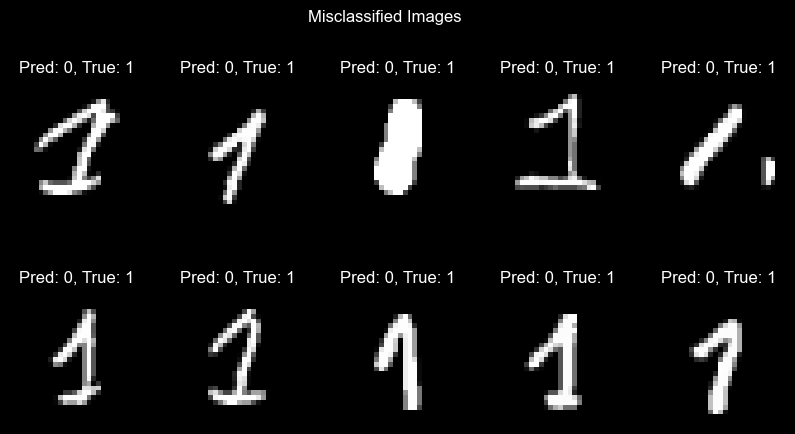

In [7]:
# Get predictions for all data points
y_pred = decision_function(X, weights, bias)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy on full dataset: {final_accuracy:.4f}")

# Find misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    n_to_show = min(len(misclassified_idx), 10)
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:n_to_show]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

### Answer the Following Question:

**Question - 8: What does misclassified_idx store, and how is it used in this code?**

It stores the array of indices where our prediction `y_pred` does not match the actual label `y`. We use these indices to pull the specific pixel data from `X` to visualize the images our model got wrong.

**Question - 9: How do you interpret the result if the output is "All images were correctly classified!"?**

It indicates that our Perceptron found a linear hyperplane that perfectly separates the 0s from the 1s in our training set, meaning the data is linearly separable.